In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data_dir = "/content/drive/MyDrive/2Model/Dataset1"

Mounted at /content/drive


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# ================================================
# CONFIG
# ================================================
# Menggunakan path yang benar secara eksplisit untuk DATASET_PATH
DATASET_PATH = "/content/drive/MyDrive/2Model/Dataset1"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

X_train_path = os.path.join(DATASET_PATH, "Xray/Train")
X_test_path  = os.path.join(DATASET_PATH, "Xray/Test")
N_train_path = os.path.join(DATASET_PATH, "Non Xray/Train")
N_test_path  = os.path.join(DATASET_PATH, "Non Xray/Test")

In [ ]:
# ================================================
# FUNCTION: LOAD FOLDER MANUAL
# ================================================
def load_folder(path, label):
    """Load all images from path and assign label."""
    images = []
    labels = []

    for fname in os.listdir(path):
        fpath = os.path.join(path, fname)
        try:
            img = tf.keras.preprocessing.image.load_img(fpath, target_size=IMG_SIZE)
            img = tf.keras.preprocessing.image.img_to_array(img)
            img = img / 255.0
            images.append(img)
            labels.append(label)
        except:
            pass  # skip corrupted files

    return np.array(images), np.array(labels)


In [ ]:
# ================================================
# LOAD TRAIN DATA
# ================================================
X_train, y_train_x = load_folder(X_train_path, 1)   # 1 = Xray
N_train, y_train_n = load_folder(N_train_path, 0)   # 0 = Non Xray

X_train_all = np.concatenate([X_train, N_train], axis=0)
y_train_all = np.concatenate([y_train_x, y_train_n], axis=0)

# ================================================
# LOAD TEST DATA
# ================================================
X_test, y_test_x = load_folder(X_test_path, 1)
N_test, y_test_n = load_folder(N_test_path, 0)

X_test_all = np.concatenate([X_test, N_test], axis=0)
y_test_all = np.concatenate([y_test_x, y_test_n], axis=0)

print("Train shape:", X_train_all.shape, y_train_all.shape)
print("Test shape:", X_test_all.shape, y_test_all.shape)

Train shape: (400, 224, 224, 3) (400,)
Test shape: (299, 224, 224, 3) (299,)


In [ ]:
# ================================================
# BUILD SIMPLE CNN MODEL
# ================================================
model1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(2, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,634 (397.01 KB)

 Trainable params: 101,634 (397.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ================================================
# TRAIN MODEL
# ================================================
history = model1.fit(
    X_train_all, y_train_all,
    validation_data=(X_test_all, y_test_all),
    epochs=10,
    batch_size=BATCH_SIZE
)

# ================================================
# SAVE MODEL (AMAN UNTUK GUI)
# ================================================
model_path = "/content/drive/MyDrive/2Model/model1_xray_filterCNN.h5"
model1.save(model_path)

print("✅ Model1 saved to:", model_path)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 54s 4s/step - accuracy: 0.5004 - loss: 0.6703 - val_accuracy: 0.5318 - val_loss: 0.6022
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 4s/step - accuracy: 0.6453 - loss: 0.5551 - val_accuracy: 0.9231 - val_loss: 0.3790
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.9397 - loss: 0.3128 - val_accuracy: 0.7826 - val_loss: 0.3609
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.9085 - loss: 0.2417 - val_accuracy: 0.9766 - val_loss: 0.1309
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 48s 4s/step - accuracy: 0.9851 - loss: 0.0695 - val_accuracy: 0.9766 - val_loss: 0.0640
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9914 - loss: 0.0380 - val_accuracy: 0.9933 - val_loss: 0.0375
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.9917 - loss: 0.0338 - val_accuracy: 0.9933 - val_loss: 0.0404
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 82s 4s/step - accuracy: 0.9981 - loss: 0.0249 - val_accuracy: 0.9632 - val_loss:

✅ Model1 saved to: /content/drive/MyDrive/2Model/model1_xray_filterCNN.h5


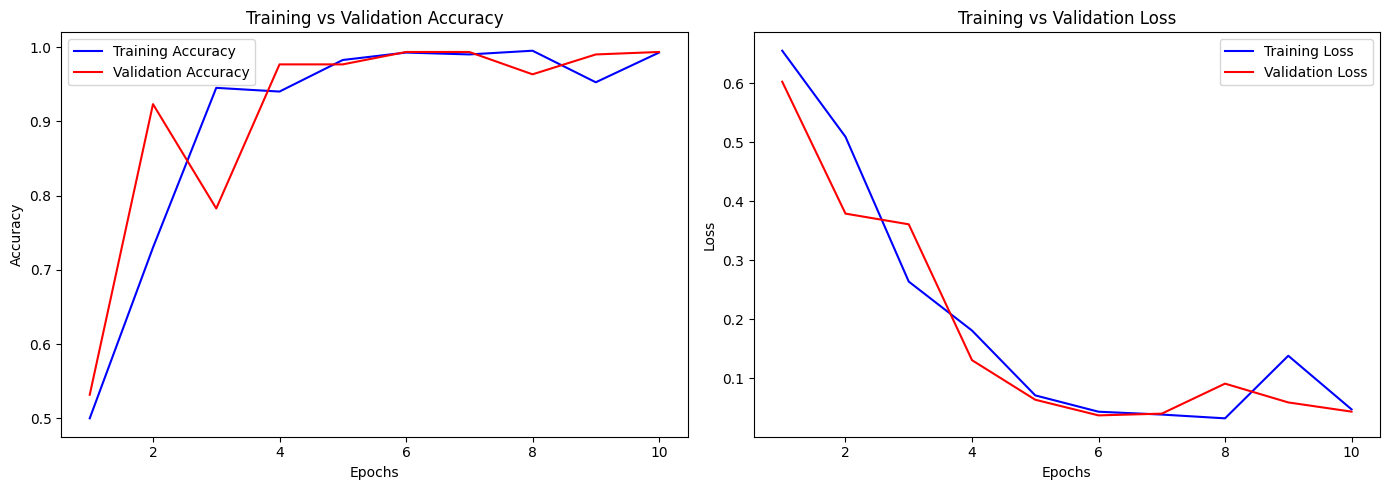

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------
# 1. PLOT TRAINING / VALIDATION ACCURACY & LOSS
# ---------------------------------------------------

def plot_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc)+1)

    plt.figure(figsize=(14,5))

    # ACCURACY
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # LOSS
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Panggil fungsi setelah training:
plot_training(history)


In [ ]:
# ==============================
# CONFIG
# ==============================
MODEL_PATH = "/content/drive/MyDrive/2Model/model1_xray_filterCNN.h5"
TEST_DIR = "/content/drive/MyDrive/2Model/Dataset1"
OUTPUT_JSON = "/content/drive/MyDrive/2Model/evaluation_metrics.json"
OUTPUT_CM_PNG = "/content/drive/MyDrive/2Model/model1_confusion_matrix_.png"

IMG_SIZE = (224, 224)
BATCH = 1

In [ ]:
import tensorflow as tf
import os # Import os for path operations

# Define MODEL_PATH locally or ensure the config cell is run first
MODEL_PATH = "/content/drive/MyDrive/2Model/model1_xray_filterCNN.h5"

if not os.path.exists(MODEL_PATH):
    print(f"Error: Model file not found at {MODEL_PATH}. Please ensure the model was trained and saved correctly by running the training cell (Gh0CsZeSJ8D2).")
else:
    model1 = tf.keras.models.load_model(MODEL_PATH, compile=False)
    model1.save("/content/drive/MyDrive/2Model/model1_xray_CNN.keras")
    print("Model loaded successfully and saved in .keras format locally.")

Model loaded successfully and saved in .keras format locally.


In [ ]:
import tensorflow as tf
from tensorflow import keras
import os

# Ensure MODEL_PATH is defined and points to the correct location
# It's already defined globally in cell 1zUgfUZ7t65H
# MODEL_PATH = "/content/drive/MyDrive/2Model/model1_xray_filterCNN.h5"

# Define the path for the fixed model
FIXED_MODEL_PATH = "/content/drive/MyDrive/2Model/model1_xray_filterCNN_fixed.keras"

if not os.path.exists(MODEL_PATH):
    print(f"Error: Model file not found at {MODEL_PATH}. Please ensure the model was trained and saved correctly.")
else:
    # Load the old model (it was a Sequential model)
    old_model = keras.models.load_model(MODEL_PATH, compile=False)

    # Rebuild the model more robustly by using its configuration
    # This ensures a clean functional graph without potential batch_shape issues
    # or conflicts from reusing loaded layer instances directly.
    new_config = old_model.get_config()

    # The original model was Sequential, so we should reconstruct it using Sequential.from_config
    new_model = keras.Sequential.from_config(new_config)

    # Transfer the trained weights from the old model to the new model
    for new_layer, old_layer in zip(new_model.layers, old_model.layers):
        new_layer.set_weights(old_layer.get_weights())

    # Save the new model in the recommended .keras format
    new_model.save(FIXED_MODEL_PATH)
    print(f"SUKSES! Model fixed disimpan sebagai {FIXED_MODEL_PATH}")

SUKSES! Model fixed disimpan sebagai /content/drive/MyDrive/2Model/model1_xray_filterCNN_fixed.keras


In [ ]:
# ==============================
# LOAD TEST DATA
# ==============================
datagen = ImageDataGenerator(rescale=1./255)

test_gen = datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)

# ==============================
# LOAD MODEL
# ==============================
model = load_model(MODEL_PATH, compile=False)

Found 699 images belonging to 2 classes.


In [ ]:
# ==============================
# PREDICT
# ==============================
y_pred = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen.classes

class_labels = list(test_gen.class_indices.keys())

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


699/699 ━━━━━━━━━━━━━━━━━━━━ 34s 48ms/step


In [ ]:
from sklearn.metrics import classification_report

report_text = classification_report(y_true, y_pred_classes, target_names=test_gen.class_indices.keys())
print(report_text)

              precision    recall  f1-score   support

    Non Xray       1.00      0.99      0.99       349
        Xray       0.99      1.00      0.99       350

    accuracy                           0.99       699
   macro avg       0.99      0.99      0.99       699
weighted avg       0.99      0.99      0.99       699



In [ ]:
# ==============================
# CLASSIFICATION REPORT
# ==============================
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_labels,
    output_dict=True
)

# Simpan JSON
with open(OUTPUT_JSON, "w") as f:
    json.dump(report, f, indent=4)

print("JSON metrics saved →", OUTPUT_JSON)

JSON metrics saved → /content/drive/MyDrive/2Model/evaluation_metrics.json


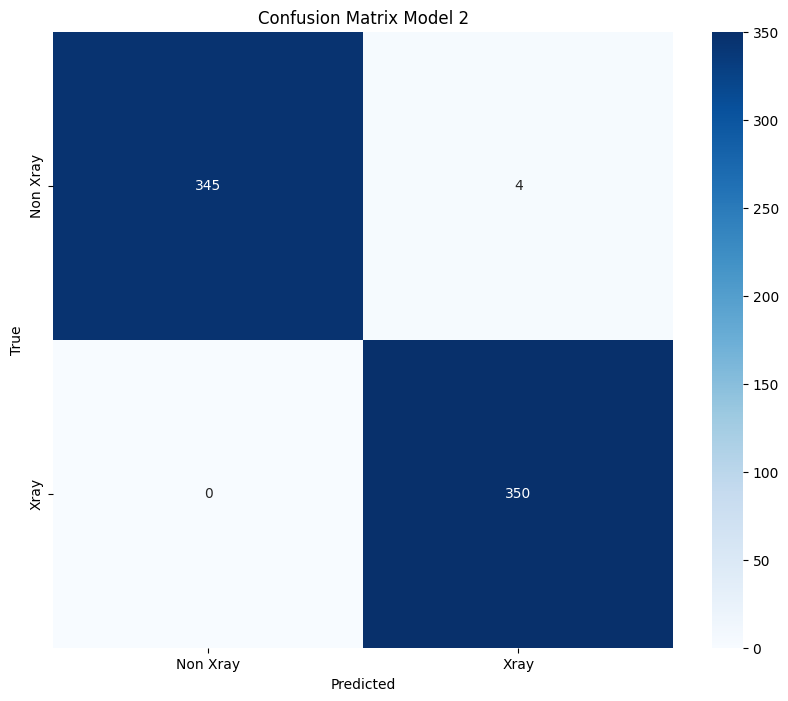

In [ ]:
# ==============================
# CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Model 2")

# WAJIB DITAMBAHKAN SUPAYA CM TAMPIL
plt.show()

# Baru kemudian simpan
plt.savefig("/content/drive/MyDrive/2Model/confusion_matrix_final.png", dpi=300, bbox_inches='tight')
plt.close()

In [ ]:
import tensorflow as tf # Ensure TensorFlow is imported

# Menggunakan tf.keras.utils.image_dataset_from_directory yang mendukung validation_split
# Pastikan struktur folder adalah Dataset1/Non Xray dan Dataset1/Xray
train_ds_initial = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, # Direktori utama, harus berisi folder 'Non Xray' dan 'Xray'
    validation_split=0.2, # Alokasikan 20% data untuk validasi
    subset="training",
    seed=123, # Penting untuk pembagian yang dapat direproduksi
    image_size=IMG_SIZE, # (224, 224)
    batch_size=BATCH,    # 1
    label_mode='int'     # Untuk sparse_categorical_crossentropy
)

validation_ds_initial = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH, # Direktori utama
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode='int'
)

# Simpan nama kelas sebelum operasi map dan prefetch
train_class_names = train_ds_initial.class_names
validation_class_names = validation_ds_initial.class_names

# Terapkan penskalaan secara eksplisit, karena image_dataset_from_directory menghasilkan tensor dalam [0, 255]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_generator = train_ds_initial.map(lambda x, y: (normalization_layer(x), y))
validation_generator = validation_ds_initial.map(lambda x, y: (normalization_layer(x), y))

# Prefetching untuk performa
train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)

print("Class names train:", train_class_names)
print("Class names validation:", validation_class_names)

# Simpan nama kelas dari generator pelatihan
class_names_map = {idx: name for idx, name in enumerate(train_class_names)}
with open("class_names_model1CNN.json", "w") as f:
    json.dump(class_names_map, f)

Found 699 files belonging to 2 classes.
Using 560 files for training.
Found 699 files belonging to 2 classes.
Using 139 files for validation.
Class names train: ['Non Xray', 'Xray']
Class names validation: ['Non Xray', 'Xray']
